# CÉLULA 1 -Importar bibliotecas e carregar o arquivo

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_theme(style="whitegrid")

# Carregar o arquivo — pular as 8 primeiras linhas de cabeçalho do INEP
df = pd.read_excel(
    'tx_rend_municipios_2024.xlsx',
    sheet_name='MUNICIPIOS ',
    skiprows=8,
    header=0
)

print(f"Shape: {df.shape}")
print(f"\nColunas principais:")
print(df.columns[:10].tolist())
print(f"\nPrimeiras linhas:")
df.head(3)

Shape: (65595, 61)

Colunas principais:
['NU_ANO_CENSO', 'NO_REGIAO', 'SG_UF', 'CO_MUNICIPIO', 'NO_MUNICIPIO', 'NO_CATEGORIA', 'NO_DEPENDENCIA', '1_CAT_FUN', '1_CAT_FUN_AI', '1_CAT_FUN_AF']

Primeiras linhas:


,NU_ANO_CENSO,NO_REGIAO,SG_UF,CO_MUNICIPIO,NO_MUNICIPIO,NO_CATEGORIA,NO_DEPENDENCIA,1_CAT_FUN,1_CAT_FUN_AI,1_CAT_FUN_AF,...,3_CAT_FUN_06,3_CAT_FUN_07,3_CAT_FUN_08,3_CAT_FUN_09,3_CAT_MED,3_CAT_MED_01,3_CAT_MED_02,3_CAT_MED_03,3_CAT_MED_04,3_CAT_MED_NS
0,2024,Norte,RO,1100015.0,Alta Floresta D'Oeste,Total,Total,96.8,97.1,96.5,...,0.3,0.3,0,0.3,0.4,0.5,0.5,0,--,--
1,2024,Norte,RO,1100015.0,Alta Floresta D'Oeste,Urbana,Total,97.1,96.8,97.4,...,0.4,0.4,0,0.4,0.5,0.6,0.6,0,--,--
2,2024,Norte,RO,1100015.0,Alta Floresta D'Oeste,Rural,Total,96.3,97.6,94.9,...,0,0,0,0,0,0,0,0,--,--


# CÉLULA 2 - Limpeza inicial e entendimento dos dados

In [4]:
# Remover colunas vazias
df = df.dropna(axis=1, how='all')

# Verificar shape após limpeza
print(f"Shape após remover colunas vazias: {df.shape}")

# Verificar valores únicos das colunas categóricas principais
print(f"\nRegiões: {df['NO_REGIAO'].unique()}")
print(f"\nCategorias: {df['NO_CATEGORIA'].unique()}")
print(f"\nDependências: {df['NO_DEPENDENCIA'].unique()}")

# Verificar nulos nas colunas principais
print(f"\nNulos por coluna principal:")
print(df[['NO_REGIAO','SG_UF','NO_MUNICIPIO','NO_CATEGORIA','NO_DEPENDENCIA']].isnull().sum())

# Confirmar que temos dados do Rio de Janeiro
rj = df[df['SG_UF'] == 'RJ']
print(f"\nRegistros do Rio de Janeiro: {len(rj)}")
print(f"Municípios únicos no RJ: {rj['NO_MUNICIPIO'].nunique()}")

Shape após remover colunas vazias: (65595, 61)

Regiões: ['Norte' 'Nordeste' 'Sudeste' 'Sul' 'Centro-Oeste' nan]

Categorias: ['Total' 'Urbana' 'Rural' nan]

Dependências: ['Total' 'Estadual' 'Municipal' 'Pública' 'Federal' 'Privada' nan]

Nulos por coluna principal:
NO_REGIAO         1
SG_UF             1
NO_MUNICIPIO      1
NO_CATEGORIA      1
NO_DEPENDENCIA    1
dtype: int64

Registros do Rio de Janeiro: 1255
Municípios únicos no RJ: 92


# CÉLULA 3 - Limpeza profunda e tratamento das colunas

In [5]:
# Remover linha nula (rodapé do Excel)
df = df.dropna(subset=['NO_REGIAO'])

# Renomear todas as colunas
df = df.rename(columns={
    'NU_ANO_CENSO'   : 'ano',
    'NO_REGIAO'      : 'regiao',
    'SG_UF'          : 'uf',
    'CO_MUNICIPIO'   : 'cod_municipio',
    'NO_MUNICIPIO'   : 'municipio',
    'NO_CATEGORIA'   : 'localizacao',
    'NO_DEPENDENCIA' : 'dependencia',

    # Aprovação — totais
    '1_CAT_FUN'      : 'aprov_fundamental',
    '1_CAT_FUN_AI'   : 'aprov_fun_anos_iniciais',
    '1_CAT_FUN_AF'   : 'aprov_fun_anos_finais',
    '1_CAT_MED'      : 'aprov_medio',

    # Aprovação — séries Fundamental
    '1_CAT_FUN_01'   : 'aprov_fun_1ano',
    '1_CAT_FUN_02'   : 'aprov_fun_2ano',
    '1_CAT_FUN_03'   : 'aprov_fun_3ano',
    '1_CAT_FUN_04'   : 'aprov_fun_4ano',
    '1_CAT_FUN_05'   : 'aprov_fun_5ano',
    '1_CAT_FUN_06'   : 'aprov_fun_6ano',
    '1_CAT_FUN_07'   : 'aprov_fun_7ano',
    '1_CAT_FUN_08'   : 'aprov_fun_8ano',
    '1_CAT_FUN_09'   : 'aprov_fun_9ano',

    # Aprovação — séries Médio
    '1_CAT_MED_01'   : 'aprov_med_1ano',
    '1_CAT_MED_02'   : 'aprov_med_2ano',
    '1_CAT_MED_03'   : 'aprov_med_3ano',
    '1_CAT_MED_04'   : 'aprov_med_4ano',
    '1_CAT_MED_NS'   : 'aprov_med_nao_seriado',

    # Reprovação — totais
    '2_CAT_FUN'      : 'reprov_fundamental',
    '2_CAT_FUN_AI'   : 'reprov_fun_anos_iniciais',
    '2_CAT_FUN_AF'   : 'reprov_fun_anos_finais',
    '2_CAT_MED'      : 'reprov_medio',

    # Reprovação — séries Fundamental
    '2_CAT_FUN_01'   : 'reprov_fun_1ano',
    '2_CAT_FUN_02'   : 'reprov_fun_2ano',
    '2_CAT_FUN_03'   : 'reprov_fun_3ano',
    '2_CAT_FUN_04'   : 'reprov_fun_4ano',
    '2_CAT_FUN_05'   : 'reprov_fun_5ano',
    '2_CAT_FUN_06'   : 'reprov_fun_6ano',
    '2_CAT_FUN_07'   : 'reprov_fun_7ano',
    '2_CAT_FUN_08'   : 'reprov_fun_8ano',
    '2_CAT_FUN_09'   : 'reprov_fun_9ano',

    # Reprovação — séries Médio
    '2_CAT_MED_01'   : 'reprov_med_1ano',
    '2_CAT_MED_02'   : 'reprov_med_2ano',
    '2_CAT_MED_03'   : 'reprov_med_3ano',
    '2_CAT_MED_04'   : 'reprov_med_4ano',
    '2_CAT_MED_NS'   : 'reprov_med_nao_seriado',

    # Abandono — totais
    '3_CAT_FUN'      : 'abandono_fundamental',
    '3_CAT_FUN_AI'   : 'abandono_fun_anos_iniciais',
    '3_CAT_FUN_AF'   : 'abandono_fun_anos_finais',
    '3_CAT_MED'      : 'abandono_medio',

    # Abandono — séries Fundamental
    '3_CAT_FUN_01'   : 'abandono_fun_1ano',
    '3_CAT_FUN_02'   : 'abandono_fun_2ano',
    '3_CAT_FUN_03'   : 'abandono_fun_3ano',
    '3_CAT_FUN_04'   : 'abandono_fun_4ano',
    '3_CAT_FUN_05'   : 'abandono_fun_5ano',
    '3_CAT_FUN_06'   : 'abandono_fun_6ano',
    '3_CAT_FUN_07'   : 'abandono_fun_7ano',
    '3_CAT_FUN_08'   : 'abandono_fun_8ano',
    '3_CAT_FUN_09'   : 'abandono_fun_9ano',

    # Abandono — séries Médio
    '3_CAT_MED_01'   : 'abandono_med_1ano',
    '3_CAT_MED_02'   : 'abandono_med_2ano',
    '3_CAT_MED_03'   : 'abandono_med_3ano',
    '3_CAT_MED_04'   : 'abandono_med_4ano',
    '3_CAT_MED_NS'   : 'abandono_med_nao_seriado',
})

print(f"Shape final: {df.shape}")
print(f"\nTotal de colunas: {len(df.columns)}")
print(f"\nColunas:")
print(df.columns.tolist())

Shape final: (65594, 61)

Total de colunas: 61

Colunas:
['ano', 'regiao', 'uf', 'cod_municipio', 'municipio', 'localizacao', 'dependencia', 'aprov_fundamental', 'aprov_fun_anos_iniciais', 'aprov_fun_anos_finais', 'aprov_fun_1ano', 'aprov_fun_2ano', 'aprov_fun_3ano', 'aprov_fun_4ano', 'aprov_fun_5ano', 'aprov_fun_6ano', 'aprov_fun_7ano', 'aprov_fun_8ano', 'aprov_fun_9ano', 'aprov_medio', 'aprov_med_1ano', 'aprov_med_2ano', 'aprov_med_3ano', 'aprov_med_4ano', 'aprov_med_nao_seriado', 'reprov_fundamental', 'reprov_fun_anos_iniciais', 'reprov_fun_anos_finais', 'reprov_fun_1ano', 'reprov_fun_2ano', 'reprov_fun_3ano', 'reprov_fun_4ano', 'reprov_fun_5ano', 'reprov_fun_6ano', 'reprov_fun_7ano', 'reprov_fun_8ano', 'reprov_fun_9ano', 'reprov_medio', 'reprov_med_1ano', 'reprov_med_2ano', 'reprov_med_3ano', 'reprov_med_4ano', 'reprov_med_nao_seriado', 'abandono_fundamental', 'abandono_fun_anos_iniciais', 'abandono_fun_anos_finais', 'abandono_fun_1ano', 'abandono_fun_2ano', 'abandono_fun_3ano', 'a

# CÉLULA 4 - Filtrar dados e tratar os traços como nulo corretamente



In [7]:
# Filtrar somente ensino regular (excluindo agregados e EJA)
# Vamos trabalhar com:
# localizacao = 'Total' → agrega urbana e rural
# dependencia = 'Total' → agrega todas as dependências

df_total = df[
    (df['localizacao'] == 'Total') &
    (df['dependencia'] == 'Total')
].copy()

# Criar recorte específico do Rio de Janeiro
df_rj = df_total[df_total['uf'] == 'RJ'].copy()

# Criar recorte do município do Rio de Janeiro
df_municipio_rj = df_total[
    df_total['municipio'] == 'Rio de Janeiro'
].copy()

# Confirmar os recortes
print(f"Dataset total (localizacao=Total, dependencia=Total): {len(df_total)} registros")
print(f"Estado do RJ: {len(df_rj)} registros")
print(f"Município Rio de Janeiro: {len(df_municipio_rj)} registros")

# Verificar municípios únicos no estado do RJ
print(f"\nMunicípios únicos no estado RJ: {df_rj['municipio'].nunique()}")

# Verificar nulos nas colunas de abandono
print(f"\nNulos nas colunas de abandono:")
abandono_cols = [c for c in df.columns if 'abandono' in c]
print(df_rj[abandono_cols].isnull().sum())

Dataset total (localizacao=Total, dependencia=Total): 5570 registros
Estado do RJ: 92 registros
Município Rio de Janeiro: 1 registros

Municípios únicos no estado RJ: 92

Nulos nas colunas de abandono:
abandono_fundamental          0
abandono_fun_anos_iniciais    0
abandono_fun_anos_finais      0
abandono_fun_1ano             0
abandono_fun_2ano             0
abandono_fun_3ano             0
abandono_fun_4ano             0
abandono_fun_5ano             0
abandono_fun_6ano             0
abandono_fun_7ano             0
abandono_fun_8ano             0
abandono_fun_9ano             0
abandono_medio                0
abandono_med_1ano             0
abandono_med_2ano             0
abandono_med_3ano             0
abandono_med_4ano             0
abandono_med_nao_seriado      0
dtype: int64


In [8]:
# Verificar se existem traços nos dados
abandono_cols = [c for c in df.columns if 'abandono' in c]
reprov_cols = [c for c in df.columns if 'reprov' in c]
aprov_cols = [c for c in df.columns if 'aprov' in c]
todas_metricas = abandono_cols + reprov_cols + aprov_cols

# Verificar quantos traços existem no dataset RJ
print("Traços encontrados por coluna no RJ:")
for col in abandono_cols:
    tracos = (df_rj[col] == '--').sum()
    if tracos > 0:
        print(f"  {col}: {tracos} traços")

# Substituir traço por NaN em todo o dataset
import numpy as np

for col in todas_metricas:
    df_total[col] = df_total[col].replace('--', np.nan)
    df_rj[col] = df_rj[col].replace('--', np.nan)
    df_municipio_rj[col] = df_municipio_rj[col].replace('--', np.nan)

# Converter colunas numéricas para float
for col in todas_metricas:
    df_total[col] = pd.to_numeric(df_total[col], errors='coerce')
    df_rj[col] = pd.to_numeric(df_rj[col], errors='coerce')
    df_municipio_rj[col] = pd.to_numeric(df_municipio_rj[col], errors='coerce')

# Verificar resultado
print(f"\nApós tratamento — nulos reais no RJ:")
for col in abandono_cols:
    nulos = df_rj[col].isnull().sum()
    if nulos > 0:
        print(f"  {col}: {nulos} nulos")

print(f"\nTipos das colunas após conversão:")
print(df_rj[abandono_cols].dtypes.unique())

Traços encontrados por coluna no RJ:
  abandono_med_4ano: 86 traços
  abandono_med_nao_seriado: 74 traços

Após tratamento — nulos reais no RJ:
  abandono_med_4ano: 86 nulos
  abandono_med_nao_seriado: 74 nulos

Tipos das colunas após conversão:
[dtype('float64')]


# CÉLULA 5 - Filtrar dados para análise

In [9]:
# Recortes por dependência — município do Rio de Janeiro
df_mun_rj_total = df[
    (df['municipio'] == 'Rio de Janeiro') &
    (df['localizacao'] == 'Total') &
    (df['dependencia'] == 'Total')
].copy()

df_mun_rj_publica = df[
    (df['municipio'] == 'Rio de Janeiro') &
    (df['localizacao'] == 'Total') &
    (df['dependencia'] == 'Pública')
].copy()

df_mun_rj_privada = df[
    (df['municipio'] == 'Rio de Janeiro') &
    (df['localizacao'] == 'Total') &
    (df['dependencia'] == 'Privada')
].copy()

df_mun_rj_municipal = df[
    (df['municipio'] == 'Rio de Janeiro') &
    (df['localizacao'] == 'Total') &
    (df['dependencia'] == 'Municipal')
].copy()

df_mun_rj_estadual = df[
    (df['municipio'] == 'Rio de Janeiro') &
    (df['localizacao'] == 'Total') &
    (df['dependencia'] == 'Estadual')
].copy()

df_mun_rj_federal = df[
    (df['municipio'] == 'Rio de Janeiro') &
    (df['localizacao'] == 'Total') &
    (df['dependencia'] == 'Federal')
].copy()

# Aplicar tratamento de traços
recortes_municipio = [
    df_mun_rj_total, df_mun_rj_publica, df_mun_rj_privada,
    df_mun_rj_municipal, df_mun_rj_estadual, df_mun_rj_federal
]

for recorte in recortes_municipio:
    for col in todas_metricas:
        recorte[col] = recorte[col].replace('--', np.nan)
        recorte[col] = pd.to_numeric(recorte[col], errors='coerce')

# Confirmar
print("Recortes do município do Rio de Janeiro:")
print(f"Total:     {len(df_mun_rj_total)} registro")
print(f"Pública:   {len(df_mun_rj_publica)} registro")
print(f"Privada:   {len(df_mun_rj_privada)} registro")
print(f"Municipal: {len(df_mun_rj_municipal)} registro")
print(f"Estadual:  {len(df_mun_rj_estadual)} registro")
print(f"Federal:   {len(df_mun_rj_federal)} registro")

# Visualizar os valores de abandono para confirmar
print("\nTaxa de abandono no Ensino Médio por dependência:")
for nome, recorte in [
    ('Total', df_mun_rj_total),
    ('Pública', df_mun_rj_publica),
    ('Privada', df_mun_rj_privada),
    ('Municipal', df_mun_rj_municipal),
    ('Estadual', df_mun_rj_estadual),
    ('Federal', df_mun_rj_federal)
]:
    valor = recorte['abandono_medio'].values[0] if len(recorte) > 0 else 'sem dado'
    print(f"  {nome}: {valor}%")

Recortes do município do Rio de Janeiro:
Total:     1 registro
Pública:   1 registro
Privada:   1 registro
Municipal: 1 registro
Estadual:  1 registro
Federal:   1 registro

Taxa de abandono no Ensino Médio por dependência:
  Total: 5.8%
  Pública: 7.6%
  Privada: 0.9%
  Municipal: nan%
  Estadual: 7.9%
  Federal: 1.2%


# CÉLULA 6 - Gráfico 1: Abandono no município do RJ por dependência

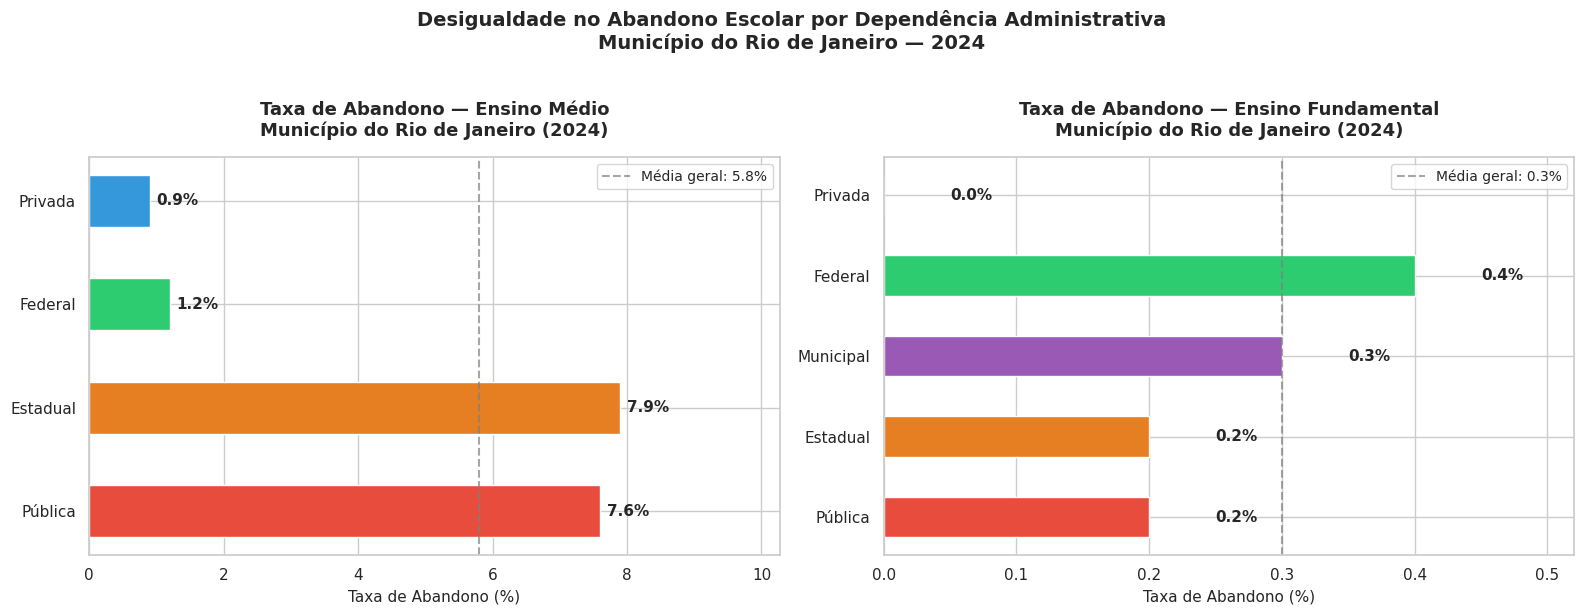

Ensino Médio:
  Pública: 7.6%
  Estadual: 7.9%
  Federal: 1.2%
  Privada: 0.9%

Ensino Fundamental:
  Pública: 0.2%
  Estadual: 0.2%
  Municipal: 0.3%
  Federal: 0.4%
  Privada: 0%


In [10]:
# Dados para o gráfico
dep_medio = ['Pública', 'Estadual', 'Federal', 'Privada']
dep_fundamental = ['Pública', 'Estadual', 'Municipal', 'Federal', 'Privada']

valores_medio = [
    df_mun_rj_publica['abandono_medio'].values[0],
    df_mun_rj_estadual['abandono_medio'].values[0],
    df_mun_rj_federal['abandono_medio'].values[0],
    df_mun_rj_privada['abandono_medio'].values[0]
]

valores_fundamental = [
    df_mun_rj_publica['abandono_fundamental'].values[0],
    df_mun_rj_estadual['abandono_fundamental'].values[0],
    df_mun_rj_municipal['abandono_fundamental'].values[0],
    df_mun_rj_federal['abandono_fundamental'].values[0],
    df_mun_rj_privada['abandono_fundamental'].values[0]
]

# Cores por dependência
cores_medio = ['#E74C3C', '#E67E22', '#2ECC71', '#3498DB']
cores_fundamental = ['#E74C3C', '#E67E22', '#9B59B6', '#2ECC71', '#3498DB']

# Configurar figura com dois subplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1a — Ensino Médio
bars1 = ax1.barh(dep_medio, valores_medio,
                  color=cores_medio, edgecolor='white', height=0.5)
ax1.set_title('Taxa de Abandono — Ensino Médio\nMunicípio do Rio de Janeiro (2024)',
              fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Taxa de Abandono (%)', fontsize=11)
ax1.set_xlim(0, max(valores_medio) * 1.3)

for bar, valor in zip(bars1, valores_medio):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{valor:.1f}%', va='center', fontsize=11, fontweight='bold')

ax1.axvline(x=df_mun_rj_total['abandono_medio'].values[0],
            color='gray', linestyle='--', alpha=0.7, label=f"Média geral: {df_mun_rj_total['abandono_medio'].values[0]:.1f}%")
ax1.legend(fontsize=10)

# Gráfico 1b — Ensino Fundamental
bars2 = ax2.barh(dep_fundamental, valores_fundamental,
                  color=cores_fundamental, edgecolor='white', height=0.5)
ax2.set_title('Taxa de Abandono — Ensino Fundamental\nMunicípio do Rio de Janeiro (2024)',
              fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('Taxa de Abandono (%)', fontsize=11)
ax2.set_xlim(0, max(valores_fundamental) * 1.3)

for bar, valor in zip(bars2, valores_fundamental):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{valor:.1f}%', va='center', fontsize=11, fontweight='bold')

ax2.axvline(x=df_mun_rj_total['abandono_fundamental'].values[0],
            color='gray', linestyle='--', alpha=0.7,
            label=f"Média geral: {df_mun_rj_total['abandono_fundamental'].values[0]:.1f}%")
ax2.legend(fontsize=10)

plt.suptitle('Desigualdade no Abandono Escolar por Dependência Administrativa\nMunicípio do Rio de Janeiro — 2024',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('grafico1_abandono_dependencia.png', dpi=150, bbox_inches='tight')
plt.show()

# Imprimir valores
print("Ensino Médio:")
for dep, val in zip(dep_medio, valores_medio):
    print(f"  {dep}: {val}%")

print("\nEnsino Fundamental:")
for dep, val in zip(dep_fundamental, valores_fundamental):
    print(f"  {dep}: {val}%")

# CÉLULA 7 - Gráfico 2: Abandono por categoria(Médio e Fundamental)

# 7.1 - Análise dos Dados por série do Ensino Médio

In [11]:
# Séries do Ensino Médio disponíveis
series_medio = ['1º Ano', '2º Ano', '3º Ano', '4º Ano']

# Valores por dependência — Ensino Médio por série
estadual = [
    df_mun_rj_estadual['abandono_med_1ano'].values[0],
    df_mun_rj_estadual['abandono_med_2ano'].values[0],
    df_mun_rj_estadual['abandono_med_3ano'].values[0],
    df_mun_rj_estadual['abandono_med_4ano'].values[0],
]

federal = [
    df_mun_rj_federal['abandono_med_1ano'].values[0],
    df_mun_rj_federal['abandono_med_2ano'].values[0],
    df_mun_rj_federal['abandono_med_3ano'].values[0],
    df_mun_rj_federal['abandono_med_4ano'].values[0],
]

privada = [
    df_mun_rj_privada['abandono_med_1ano'].values[0],
    df_mun_rj_privada['abandono_med_2ano'].values[0],
    df_mun_rj_privada['abandono_med_3ano'].values[0],
    df_mun_rj_privada['abandono_med_4ano'].values[0],
]

print("Valores por série — Ensino Médio:")
print("\nEstadual:")
for s, v in zip(series_medio, estadual):
    print(f"  {s}: {v}%")
print("\nFederal:")
for s, v in zip(series_medio, federal):
    print(f"  {s}: {v}%")
print("\nPrivada:")
for s, v in zip(series_medio, privada):
    print(f"  {s}: {v}%")

Valores por série — Ensino Médio:

Estadual:
  1º Ano: 8.8%
  2º Ano: 8.1%
  3º Ano: 6.3%
  4º Ano: nan%

Federal:
  1º Ano: 0.3%
  2º Ano: 0.4%
  3º Ano: 0.3%
  4º Ano: 1.1%

Privada:
  1º Ano: 0.4%
  2º Ano: 0.2%
  3º Ano: 0.2%
  4º Ano: nan%


# 7.2 - Gráfico: Abandono por série do Ensino Médio

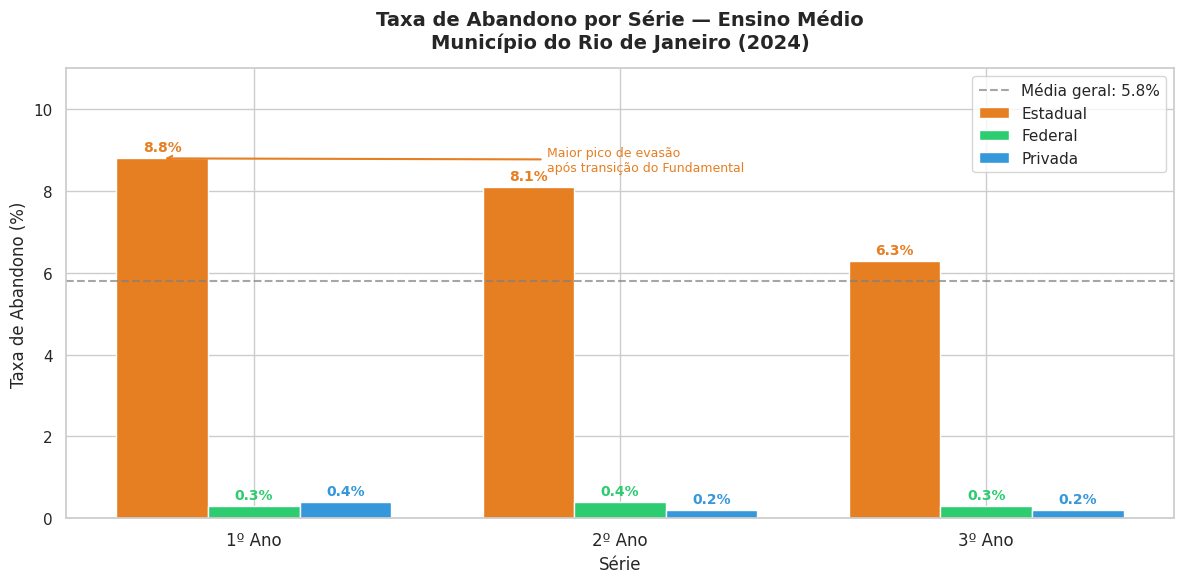


Nota: 4º ano do Ensino Médio Federal → 1.1% de abandono
Característico de cursos técnicos integrados (CEFET, IFF)
Estadual e Privada não registram 4º ano no município do RJ


In [12]:
import numpy as np

# Configurar posições das barras
x = np.arange(3)  # só 3 séries para Estadual e Privada
largura = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

# Barras por dependência — só 1º, 2º e 3º ano
barras_estadual = ax.bar(x - largura, estadual[:3],
                          largura, label='Estadual',
                          color='#E67E22', edgecolor='white')

barras_federal = ax.bar(x, federal[:3],
                         largura, label='Federal',
                         color='#2ECC71', edgecolor='white')

barras_privada = ax.bar(x + largura, privada[:3],
                         largura, label='Privada',
                         color='#3498DB', edgecolor='white')

# Adicionar valores nas barras
for bar in barras_estadual:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#E67E22')

for bar in barras_federal:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#2ECC71')

for bar in barras_privada:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#3498DB')

# Configurações do gráfico
ax.set_title('Taxa de Abandono por Série — Ensino Médio\nMunicípio do Rio de Janeiro (2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Série', fontsize=12)
ax.set_ylabel('Taxa de Abandono (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(['1º Ano', '2º Ano', '3º Ano'], fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, max(estadual[:3]) * 1.25)

# Linha de referência — média geral do Ensino Médio
media_medio = df_mun_rj_total['abandono_medio'].values[0]
ax.axhline(y=media_medio, color='gray', linestyle='--',
           alpha=0.7, label=f'Média geral: {media_medio:.1f}%')
ax.legend(fontsize=11)

# Anotação explicativa no 1º ano
ax.annotate('Maior pico de evasão\napós transição do Fundamental',
            xy=(x[0] - largura, estadual[0]),
            xytext=(0.8, 8.5),
            fontsize=9,
            color='#E67E22',
            arrowprops=dict(arrowstyle='->', color='#E67E22', lw=1.5))

plt.tight_layout()
plt.savefig('grafico2_abandono_series_medio.png', dpi=150, bbox_inches='tight')
plt.show()

# Nota sobre 4º ano Federal
print("\nNota: 4º ano do Ensino Médio Federal → 1.1% de abandono")
print("Característico de cursos técnicos integrados (CEFET, IFF)")
print("Estadual e Privada não registram 4º ano no município do RJ")

# 7.3 - Análise dos Dados por série do Ensino Fundamental

In [13]:
# Séries do Ensino Fundamental
series_fundamental = [
    '1º Ano', '2º Ano', '3º Ano', '4º Ano', '5º Ano',
    '6º Ano', '7º Ano', '8º Ano', '9º Ano'
]

# Valores por dependência
estadual_fun = [
    df_mun_rj_estadual['abandono_fun_1ano'].values[0],
    df_mun_rj_estadual['abandono_fun_2ano'].values[0],
    df_mun_rj_estadual['abandono_fun_3ano'].values[0],
    df_mun_rj_estadual['abandono_fun_4ano'].values[0],
    df_mun_rj_estadual['abandono_fun_5ano'].values[0],
    df_mun_rj_estadual['abandono_fun_6ano'].values[0],
    df_mun_rj_estadual['abandono_fun_7ano'].values[0],
    df_mun_rj_estadual['abandono_fun_8ano'].values[0],
    df_mun_rj_estadual['abandono_fun_9ano'].values[0],
]

municipal_fun = [
    df_mun_rj_municipal['abandono_fun_1ano'].values[0],
    df_mun_rj_municipal['abandono_fun_2ano'].values[0],
    df_mun_rj_municipal['abandono_fun_3ano'].values[0],
    df_mun_rj_municipal['abandono_fun_4ano'].values[0],
    df_mun_rj_municipal['abandono_fun_5ano'].values[0],
    df_mun_rj_municipal['abandono_fun_6ano'].values[0],
    df_mun_rj_municipal['abandono_fun_7ano'].values[0],
    df_mun_rj_municipal['abandono_fun_8ano'].values[0],
    df_mun_rj_municipal['abandono_fun_9ano'].values[0],
]

federal_fun = [
    df_mun_rj_federal['abandono_fun_1ano'].values[0],
    df_mun_rj_federal['abandono_fun_2ano'].values[0],
    df_mun_rj_federal['abandono_fun_3ano'].values[0],
    df_mun_rj_federal['abandono_fun_4ano'].values[0],
    df_mun_rj_federal['abandono_fun_5ano'].values[0],
    df_mun_rj_federal['abandono_fun_6ano'].values[0],
    df_mun_rj_federal['abandono_fun_7ano'].values[0],
    df_mun_rj_federal['abandono_fun_8ano'].values[0],
    df_mun_rj_federal['abandono_fun_9ano'].values[0],
]

privada_fun = [
    df_mun_rj_privada['abandono_fun_1ano'].values[0],
    df_mun_rj_privada['abandono_fun_2ano'].values[0],
    df_mun_rj_privada['abandono_fun_3ano'].values[0],
    df_mun_rj_privada['abandono_fun_4ano'].values[0],
    df_mun_rj_privada['abandono_fun_5ano'].values[0],
    df_mun_rj_privada['abandono_fun_6ano'].values[0],
    df_mun_rj_privada['abandono_fun_7ano'].values[0],
    df_mun_rj_privada['abandono_fun_8ano'].values[0],
    df_mun_rj_privada['abandono_fun_9ano'].values[0],
]

# Imprimir valores antes do gráfico
print("Abandono por série — Ensino Fundamental:")
print(f"\n{'Série':<10} {'Estadual':>10} {'Municipal':>10} {'Federal':>10} {'Privada':>10}")
print("-" * 50)
for i, serie in enumerate(series_fundamental):
    print(f"{serie:<10} {str(estadual_fun[i]):>10} {str(municipal_fun[i]):>10} {str(federal_fun[i]):>10} {str(privada_fun[i]):>10}")

Abandono por série — Ensino Fundamental:

Série        Estadual  Municipal    Federal    Privada
--------------------------------------------------
1º Ano              0        0.2        5.1        0.1
2º Ano              0        0.1        2.6        0.1
3º Ano              0        0.1        0.7          0
4º Ano              0        0.1          0        0.1
5º Ano              0        0.2          0          0
6º Ano            0.2        0.4          0        0.1
7º Ano              0        0.4          0          0
8º Ano            0.6        0.5        0.1        0.1
9º Ano            0.4        0.4          0        0.1


# 7.4 - Gráfico: Abandono por série do Ensino Fundamental

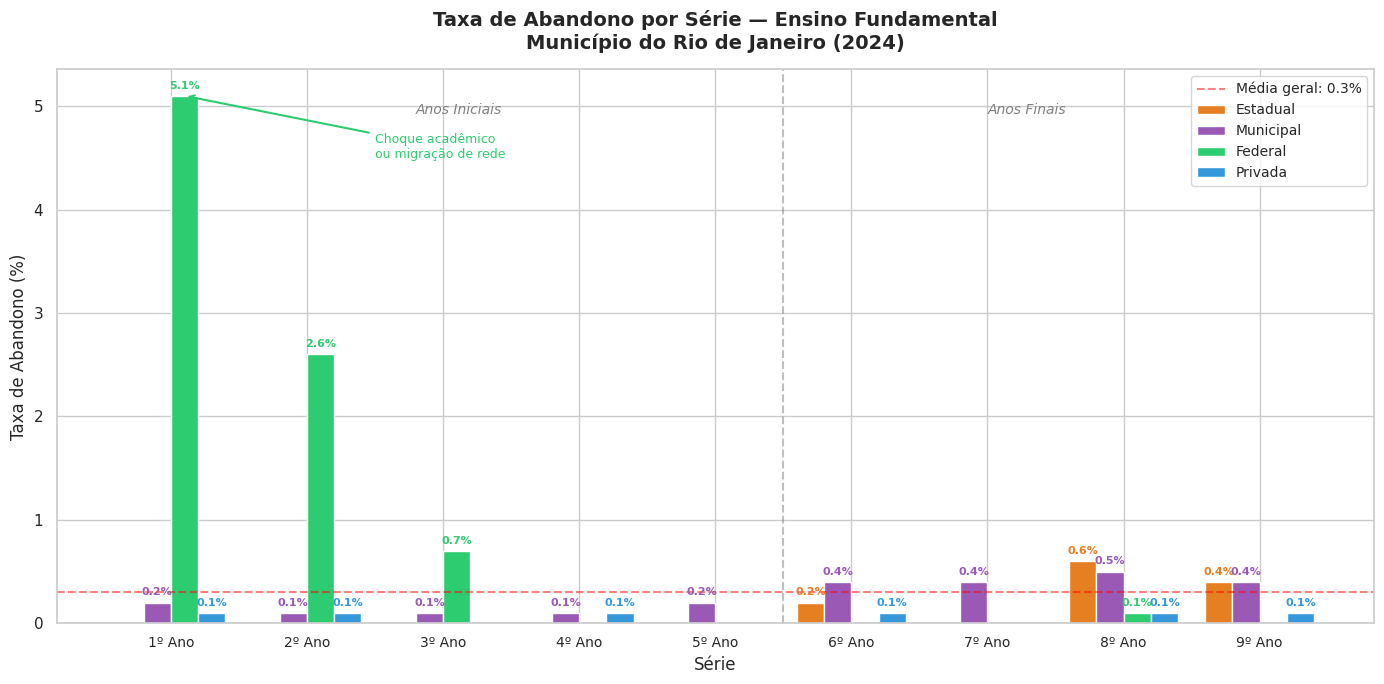

In [14]:
# Posições das barras
x = np.arange(9)
largura = 0.2

fig, ax = plt.subplots(figsize=(14, 7))

# Barras por dependência
barras_estadual = ax.bar(x - largura*1.5, estadual_fun,
                          largura, label='Estadual',
                          color='#E67E22', edgecolor='white')

barras_municipal = ax.bar(x - largura*0.5, municipal_fun,
                           largura, label='Municipal',
                           color='#9B59B6', edgecolor='white')

barras_federal = ax.bar(x + largura*0.5, federal_fun,
                         largura, label='Federal',
                         color='#2ECC71', edgecolor='white')

barras_privada = ax.bar(x + largura*1.5, privada_fun,
                         largura, label='Privada',
                         color='#3498DB', edgecolor='white')

# Adicionar valores nas barras com valor > 0
for barras, valores, cor in [
    (barras_estadual, estadual_fun, '#E67E22'),
    (barras_municipal, municipal_fun, '#9B59B6'),
    (barras_federal, federal_fun, '#2ECC71'),
    (barras_privada, privada_fun, '#3498DB')
]:
    for bar, valor in zip(barras, valores):
        if valor > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.05,
                    f'{valor:.1f}%',
                    ha='center', va='bottom',
                    fontsize=8, fontweight='bold', color=cor)

# Configurações do gráfico
ax.set_title('Taxa de Abandono por Série — Ensino Fundamental\nMunicípio do Rio de Janeiro (2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Série', fontsize=12)
ax.set_ylabel('Taxa de Abandono (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(series_fundamental, fontsize=10)
ax.legend(fontsize=11)

# Linha separando anos iniciais dos anos finais
ax.axvline(x=4.5, color='gray', linestyle='--', alpha=0.5)
ax.text(1.8, ax.get_ylim()[1] * 0.92, 'Anos Iniciais',
        fontsize=10, color='gray', style='italic')
ax.text(6.0, ax.get_ylim()[1] * 0.92, 'Anos Finais',
        fontsize=10, color='gray', style='italic')

# Anotação no Federal
ax.annotate('Choque acadêmico\nou migração de rede',
            xy=(0 + largura*0.5, federal_fun[0]),
            xytext=(1.5, 4.5),
            fontsize=9,
            color='#2ECC71',
            arrowprops=dict(arrowstyle='->', color='#2ECC71', lw=1.5))

# Linha de referência — média geral fundamental
media_fun = df_mun_rj_total['abandono_fundamental'].values[0]
ax.axhline(y=media_fun, color='red', linestyle='--',
           alpha=0.5, label=f'Média geral: {media_fun:.1f}%')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('grafico3_abandono_series_fundamental.png', dpi=150, bbox_inches='tight')
plt.show()

# CÉLULA 8 - ANÁLISE E GRÁFICO: COMPARATIVO ENTRE RIO DE JANEIRO X BRASIL

# 8.1 - Análise dos Dados - RJ X BRASIL

In [15]:
# Comparativo RJ x Brasil
# Médias nacionais vs estado do RJ

# Brasil — média nacional
media_brasil_medio = df_total['abandono_medio'].mean()
media_brasil_fundamental = df_total['abandono_fundamental'].mean()
media_brasil_fun_iniciais = df_total['abandono_fun_anos_iniciais'].mean()
media_brasil_fun_finais = df_total['abandono_fun_anos_finais'].mean()

# Estado do RJ — média dos 92 municípios
media_rj_medio = df_rj['abandono_medio'].mean()
media_rj_fundamental = df_rj['abandono_fundamental'].mean()
media_rj_fun_iniciais = df_rj['abandono_fun_anos_iniciais'].mean()
media_rj_fun_finais = df_rj['abandono_fun_anos_finais'].mean()

# Município do Rio de Janeiro
municipio_medio = df_mun_rj_total['abandono_medio'].values[0]
municipio_fundamental = df_mun_rj_total['abandono_fundamental'].values[0]
municipio_fun_iniciais = df_mun_rj_total['abandono_fun_anos_iniciais'].values[0]
municipio_fun_finais = df_mun_rj_total['abandono_fun_anos_finais'].values[0]

print("=" * 55)
print(f"{'Indicador':<30} {'Brasil':>8} {'Estado RJ':>8} {'Mun. RJ':>8}")
print("=" * 55)
print(f"{'Abandono Ensino Médio':<30} {media_brasil_medio:>7.2f}% {media_rj_medio:>7.2f}% {municipio_medio:>7.2f}%")
print(f"{'Abandono Fundamental':<30} {media_brasil_fundamental:>7.2f}% {media_rj_fundamental:>7.2f}% {municipio_fundamental:>7.2f}%")
print(f"{'Abandono Anos Iniciais':<30} {media_brasil_fun_iniciais:>7.2f}% {media_rj_fun_iniciais:>7.2f}% {municipio_fun_iniciais:>7.2f}%")
print(f"{'Abandono Anos Finais':<30} {media_brasil_fun_finais:>7.2f}% {media_rj_fun_finais:>7.2f}% {municipio_fun_finais:>7.2f}%")
print("=" * 55)

# Diferença percentual RJ x Brasil
print(f"\nDiferença Estado RJ vs Brasil:")
print(f"  Ensino Médio:    {media_rj_medio - media_brasil_medio:+.2f} pontos percentuais")
print(f"  Fundamental:     {media_rj_fundamental - media_brasil_fundamental:+.2f} pontos percentuais")
print(f"  Anos Iniciais:   {media_rj_fun_iniciais - media_brasil_fun_iniciais:+.2f} pontos percentuais")
print(f"  Anos Finais:     {media_rj_fun_finais - media_brasil_fun_finais:+.2f} pontos percentuais")

print(f"\nDiferença Município RJ vs Brasil:")
print(f"  Ensino Médio:    {municipio_medio - media_brasil_medio:+.2f} pontos percentuais")
print(f"  Fundamental:     {municipio_fundamental - media_brasil_fundamental:+.2f} pontos percentuais")

Indicador                        Brasil Estado RJ  Mun. RJ
Abandono Ensino Médio             3.40%    2.95%    5.80%
Abandono Fundamental              0.62%    0.35%    0.30%
Abandono Anos Iniciais            0.18%    0.18%    0.20%
Abandono Anos Finais              1.16%    0.57%    0.30%

Diferença Estado RJ vs Brasil:
  Ensino Médio:    -0.45 pontos percentuais
  Fundamental:     -0.28 pontos percentuais
  Anos Iniciais:   +0.00 pontos percentuais
  Anos Finais:     -0.59 pontos percentuais

Diferença Município RJ vs Brasil:
  Ensino Médio:    +2.40 pontos percentuais
  Fundamental:     -0.32 pontos percentuais


# 8.2 - Listagem das capitais

In [16]:
# Lista das capitais brasileiras
capitais = {
    'AC': 'Rio Branco',
    'AL': 'Maceió',
    'AM': 'Manaus',
    'AP': 'Macapá',
    'BA': 'Salvador',
    'CE': 'Fortaleza',
    'DF': 'Brasília',
    'ES': 'Vitória',
    'GO': 'Goiânia',
    'MA': 'São Luís',
    'MG': 'Belo Horizonte',
    'MS': 'Campo Grande',
    'MT': 'Cuiabá',
    'PA': 'Belém',
    'PB': 'João Pessoa',
    'PE': 'Recife',
    'PI': 'Teresina',
    'PR': 'Curitiba',
    'RJ': 'Rio de Janeiro',
    'RN': 'Natal',
    'RO': 'Porto Velho',
    'RR': 'Boa Vista',
    'RS': 'Porto Alegre',
    'SC': 'Florianópolis',
    'SE': 'Aracaju',
    'SP': 'São Paulo',
    'TO': 'Palmas'
}

# Filtrar somente capitais no dataset
condicoes = [
    (df_total['uf'] == uf) & (df_total['municipio'] == capital)
    for uf, capital in capitais.items()
]

import functools
df_capitais = df_total[functools.reduce(lambda a, b: a | b, condicoes)].copy()

# Confirmar quantas capitais encontramos
print(f"\nCapitais encontradas no dataset: {len(df_capitais)}")
print(df_capitais[['uf', 'municipio', 'abandono_medio', 'abandono_fundamental']].to_string(index=False))


Capitais encontradas no dataset: 27
uf      municipio  abandono_medio  abandono_fundamental
RO    Porto Velho             4.5                   1.0
AC     Rio Branco             2.8                   0.5
AM         Manaus             3.1                   0.5
RR      Boa Vista             2.6                   0.5
PA          Belém             1.6                   0.6
AP         Macapá             2.6                   0.6
TO         Palmas             2.3                   0.1
MA       São Luís             1.4                   0.8
PI       Teresina             1.4                   0.2
CE      Fortaleza             2.3                   0.2
RN          Natal             6.4                   1.3
PB    João Pessoa             6.0                   1.3
PE         Recife             0.6                   0.2
AL         Maceió             3.3                   1.1
SE        Aracaju             0.7                   0.2
BA       Salvador             6.7                   1.8
MG Belo Hor

# 8.3 - Ranking de abandono por capitais

In [17]:
# Ranking por abandono no Ensino Médio
df_capitais_sorted_medio = df_capitais.sort_values(
    'abandono_medio', ascending=False
).reset_index(drop=True)

df_capitais_sorted_medio.index += 1  # ranking começa em 1

print("RANKING — Abandono Ensino Médio nas Capitais:")
print("=" * 50)
for idx, row in df_capitais_sorted_medio.iterrows():
    destaque = " ← Rio de Janeiro" if row['municipio'] == 'Rio de Janeiro' else ""
    print(f"{idx:>2}º {row['municipio']:<20} {row['abandono_medio']:>5.1f}%{destaque}")

print(f"\nMédia das capitais: {df_capitais['abandono_medio'].mean():.2f}%")
print(f"Média Brasil:       {media_brasil_medio:.2f}%")

# Ranking por abandono no Ensino Fundamental
df_capitais_sorted_fun = df_capitais.sort_values(
    'abandono_fundamental', ascending=False
).reset_index(drop=True)

df_capitais_sorted_fun.index += 1

print("\n\nRANKING — Abandono Ensino Fundamental nas Capitais:")
print("=" * 50)
for idx, row in df_capitais_sorted_fun.iterrows():
    destaque = " ← Rio de Janeiro" if row['municipio'] == 'Rio de Janeiro' else ""
    print(f"{idx:>2}º {row['municipio']:<20} {row['abandono_fundamental']:>5.1f}%{destaque}")

print(f"\nMédia das capitais: {df_capitais['abandono_fundamental'].mean():.2f}%")
print(f"Média Brasil:       {media_brasil_fundamental:.2f}%")

RANKING — Abandono Ensino Médio nas Capitais:
 1º Salvador               6.7%
 2º Natal                  6.4%
 3º João Pessoa            6.0%
 4º Rio de Janeiro         5.8% ← Rio de Janeiro
 5º Belo Horizonte         5.7%
 6º Porto Velho            4.5%
 7º Porto Alegre           4.3%
 8º Maceió                 3.3%
 9º Florianópolis          3.1%
10º Manaus                 3.1%
11º Cuiabá                 2.9%
12º Rio Branco             2.8%
13º Brasília               2.7%
14º Boa Vista              2.6%
15º Macapá                 2.6%
16º Vitória                2.4%
17º Palmas                 2.3%
18º Fortaleza              2.3%
19º São Paulo              2.1%
20º Campo Grande           1.8%
21º Belém                  1.6%
22º São Luís               1.4%
23º Teresina               1.4%
24º Goiânia                0.9%
25º Curitiba               0.8%
26º Aracaju                0.7%
27º Recife                 0.6%

Média das capitais: 2.99%
Média Brasil:       3.40%


RANKING — Abandono

# 8.4 - Gráfico - Comparativo município RJ x média Brasil; Ensino Fundamental e Médio

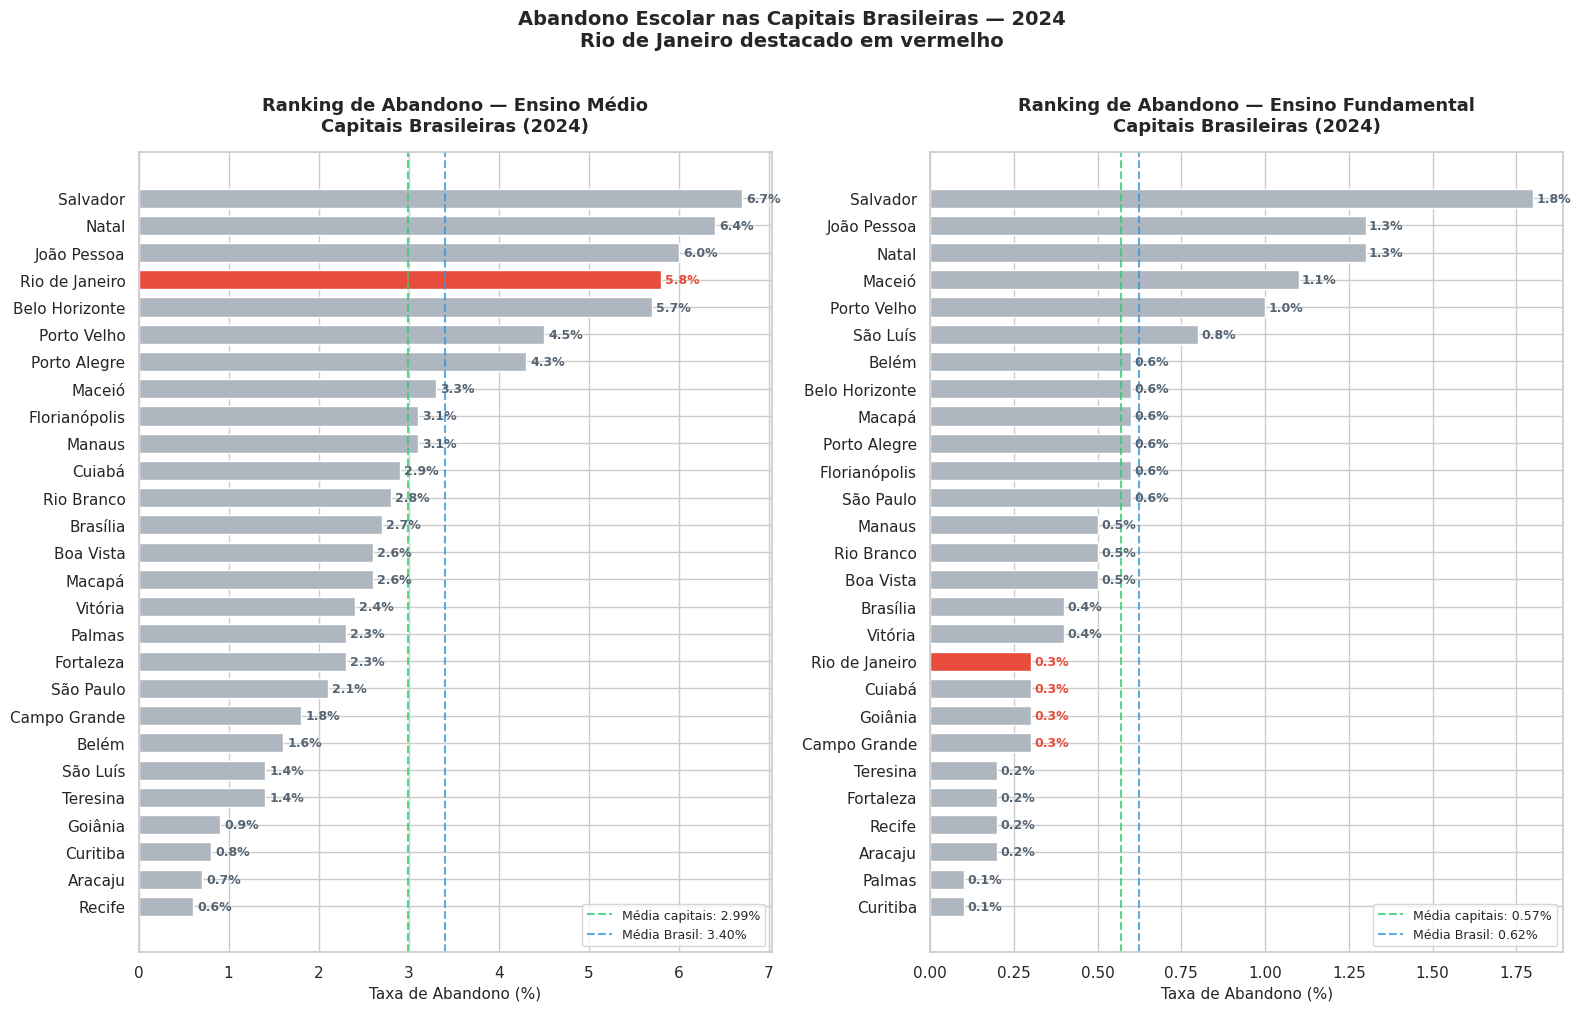

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

# Cores — destacar Rio de Janeiro
cores_medio = ['#E74C3C' if m == 'Rio de Janeiro' else '#AEB6BF'
               for m in df_capitais_sorted_medio['municipio']]

cores_fun = ['#E74C3C' if m == 'Rio de Janeiro' else '#AEB6BF'
             for m in df_capitais_sorted_fun['municipio']]

# Gráfico 1 — Ensino Médio
bars1 = ax1.barh(
    df_capitais_sorted_medio['municipio'],
    df_capitais_sorted_medio['abandono_medio'],
    color=cores_medio, edgecolor='white', height=0.7
)

# Valores nas barras
for bar, valor in zip(bars1, df_capitais_sorted_medio['abandono_medio']):
    ax1.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{valor:.1f}%', va='center', fontsize=9,
             fontweight='bold',
             color='#E74C3C' if valor == 5.8 else '#566573')

# Linha de média das capitais
media_cap_medio = df_capitais['abandono_medio'].mean()
ax1.axvline(x=media_cap_medio, color='#2ECC71', linestyle='--',
            alpha=0.8, label=f'Média capitais: {media_cap_medio:.2f}%')
ax1.axvline(x=media_brasil_medio, color='#3498DB', linestyle='--',
            alpha=0.8, label=f'Média Brasil: {media_brasil_medio:.2f}%')

ax1.set_title('Ranking de Abandono — Ensino Médio\nCapitais Brasileiras (2024)',
              fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Taxa de Abandono (%)', fontsize=11)
ax1.invert_yaxis()
ax1.legend(fontsize=9)

# Gráfico 2 — Ensino Fundamental
bars2 = ax2.barh(
    df_capitais_sorted_fun['municipio'],
    df_capitais_sorted_fun['abandono_fundamental'],
    color=cores_fun, edgecolor='white', height=0.7
)

# Valores nas barras
for bar, valor in zip(bars2, df_capitais_sorted_fun['abandono_fundamental']):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{valor:.1f}%', va='center', fontsize=9,
             fontweight='bold',
             color='#E74C3C' if valor == 0.3 and bar.get_y() > 8 else '#566573')

# Linha de média das capitais
media_cap_fun = df_capitais['abandono_fundamental'].mean()
ax2.axvline(x=media_cap_fun, color='#2ECC71', linestyle='--',
            alpha=0.8, label=f'Média capitais: {media_cap_fun:.2f}%')
ax2.axvline(x=media_brasil_fundamental, color='#3498DB', linestyle='--',
            alpha=0.8, label=f'Média Brasil: {media_brasil_fundamental:.2f}%')

ax2.set_title('Ranking de Abandono — Ensino Fundamental\nCapitais Brasileiras (2024)',
              fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('Taxa de Abandono (%)', fontsize=11)
ax2.invert_yaxis()
ax2.legend(fontsize=9)

plt.suptitle('Abandono Escolar nas Capitais Brasileiras — 2024\nRio de Janeiro destacado em vermelho',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('grafico4_ranking_capitais.png', dpi=150, bbox_inches='tight')
plt.show()

# 8.5 - Análise: Comparativo município RJ x média Brasil por dependência

In [19]:
# Médias nacionais por dependência
df_estadual_brasil = df[
    (df['localizacao'] == 'Total') &
    (df['dependencia'] == 'Estadual')
].copy()

df_federal_brasil = df[
    (df['localizacao'] == 'Total') &
    (df['dependencia'] == 'Federal')
].copy()

df_privada_brasil = df[
    (df['localizacao'] == 'Total') &
    (df['dependencia'] == 'Privada')
].copy()

df_municipal_brasil = df[
    (df['localizacao'] == 'Total') &
    (df['dependencia'] == 'Municipal')
].copy()

# Aplicar tratamento
for recorte in [df_estadual_brasil, df_federal_brasil,
                df_privada_brasil, df_municipal_brasil]:
    for col in todas_metricas:
        recorte[col] = recorte[col].replace('--', np.nan)
        recorte[col] = pd.to_numeric(recorte[col], errors='coerce')

# Montar tabela comparativa
print("=" * 65)
print(f"{'Dependência':<12} {'Indicador':<25} {'Brasil':>8} {'Mun. RJ':>8} {'Dif.':>8}")
print("=" * 65)

comparativos = [
    ('Estadual',  'abandono_medio',       df_estadual_brasil,  df_mun_rj_estadual,  'Abandono Médio'),
    ('Estadual',  'abandono_fundamental', df_estadual_brasil,  df_mun_rj_estadual,  'Abandono Fund.'),
    ('Federal',   'abandono_medio',       df_federal_brasil,   df_mun_rj_federal,   'Abandono Médio'),
    ('Federal',   'abandono_fundamental', df_federal_brasil,   df_mun_rj_federal,   'Abandono Fund.'),
    ('Municipal', 'abandono_fundamental', df_municipal_brasil, df_mun_rj_municipal, 'Abandono Fund.'),
    ('Privada',   'abandono_medio',       df_privada_brasil,   df_mun_rj_privada,   'Abandono Médio'),
    ('Privada',   'abandono_fundamental', df_privada_brasil,   df_mun_rj_privada,   'Abandono Fund.'),
]

for dep, col, df_br, df_rj, label in comparativos:
    media_br = df_br[col].mean()
    valor_rj = df_rj[col].values[0]
    diferenca = valor_rj - media_br
    sinal = "▲" if diferenca > 0 else "▼"
    print(f"{dep:<12} {label:<25} {media_br:>7.2f}% {valor_rj:>7.2f}% {sinal}{abs(diferenca):>6.2f}%")

print("=" * 65)
print("▲ = município RJ acima da média Brasil")
print("▼ = município RJ abaixo da média Brasil")

Dependência  Indicador                   Brasil  Mun. RJ     Dif.
Estadual     Abandono Médio               3.55%    7.90% ▲  4.35%
Estadual     Abandono Fund.               0.90%    0.20% ▼  0.70%
Federal      Abandono Médio               1.30%    1.20% ▼  0.10%
Federal      Abandono Fund.               0.06%    0.40% ▲  0.34%
Municipal    Abandono Fund.               0.51%    0.30% ▼  0.21%
Privada      Abandono Médio               0.59%    0.90% ▲  0.31%
Privada      Abandono Fund.               0.10%    0.00% ▼  0.10%
▲ = município RJ acima da média Brasil
▼ = município RJ abaixo da média Brasil


# 8.6 - Gráfico - Comparativo município RJ x média Brasil por dependência

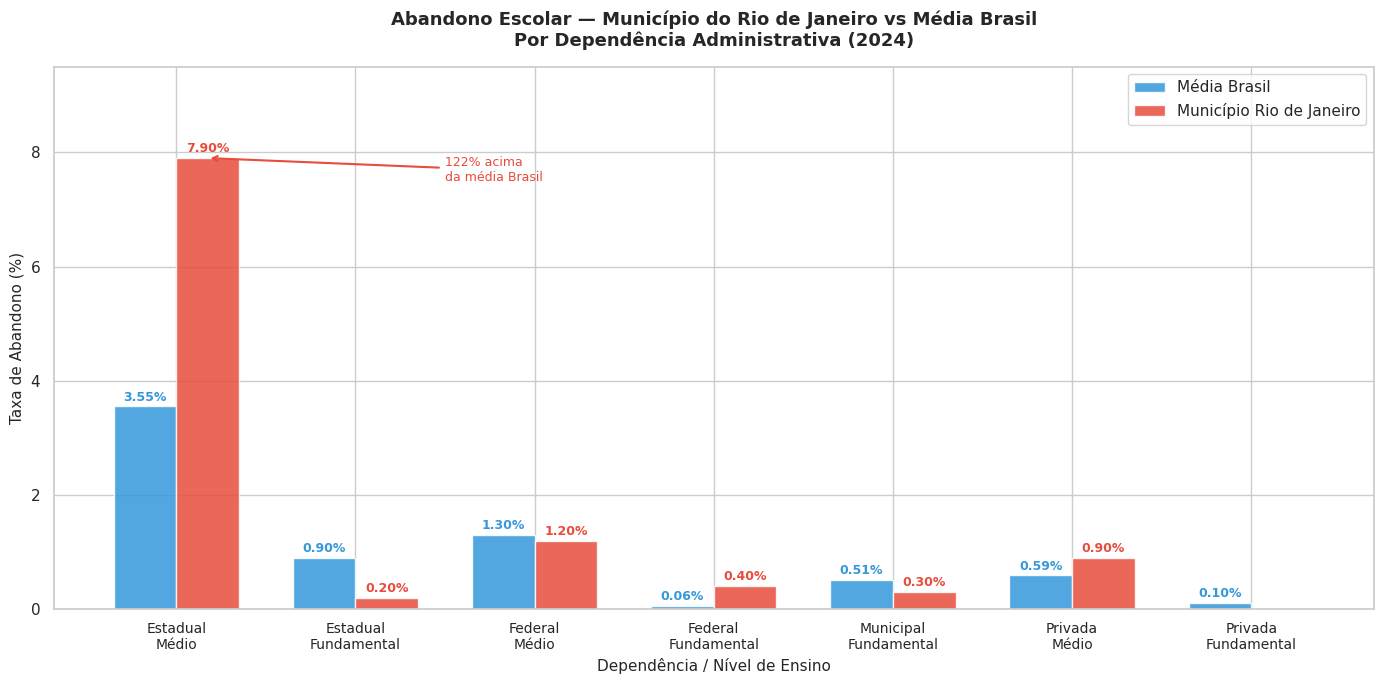

In [20]:
# Dados para o gráfico
dependencias_labels = [
    'Estadual\nMédio', 'Estadual\nFundamental',
    'Federal\nMédio', 'Federal\nFundamental',
    'Municipal\nFundamental', 'Privada\nMédio',
    'Privada\nFundamental'
]

valores_brasil = [3.55, 0.90, 1.30, 0.06, 0.51, 0.59, 0.10]
valores_rj     = [7.90, 0.20, 1.20, 0.40, 0.30, 0.90, 0.00]

x = np.arange(len(dependencias_labels))
largura = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

barras_brasil = ax.bar(x - largura/2, valores_brasil,
                        largura, label='Média Brasil',
                        color='#3498DB', edgecolor='white', alpha=0.85)

barras_rj = ax.bar(x + largura/2, valores_rj,
                    largura, label='Município Rio de Janeiro',
                    color='#E74C3C', edgecolor='white', alpha=0.85)

# Valores nas barras
for bar, valor in zip(barras_brasil, valores_brasil):
    if valor > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.05,
                f'{valor:.2f}%', ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='#3498DB')

for bar, valor in zip(barras_rj, valores_rj):
    if valor > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.05,
                f'{valor:.2f}%', ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='#E74C3C')

# Destacar barra crítica — Estadual Médio RJ
ax.annotate('122% acima\nda média Brasil',
            xy=(x[0] + largura/2, 7.90),
            xytext=(1.5, 7.5),
            fontsize=9, color='#E74C3C',
            arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.5))

ax.set_title('Abandono Escolar — Município do Rio de Janeiro vs Média Brasil\nPor Dependência Administrativa (2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Dependência / Nível de Ensino', fontsize=11)
ax.set_ylabel('Taxa de Abandono (%)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(dependencias_labels, fontsize=10)
ax.legend(fontsize=11)
ax.set_ylim(0, 9.5)

plt.tight_layout()
plt.savefig('grafico5_comparativo_dependencia.png', dpi=150, bbox_inches='tight')
plt.show()

# CÉLULA 9 - Análise com Seaborn - Visualizações Estatísticas


# 9.1 - Análise dos dados - Construção matriz Heatmap de abandono por série e dependência

In [21]:
# Montar matriz para o heatmap
# Linhas = dependências, Colunas = séries do Ensino Médio

series_med = ['1º Ano', '2º Ano', '3º Ano']

dados_heatmap_medio = {
    'Estadual': [
        df_mun_rj_estadual['abandono_med_1ano'].values[0],
        df_mun_rj_estadual['abandono_med_2ano'].values[0],
        df_mun_rj_estadual['abandono_med_3ano'].values[0],
    ],
    'Federal': [
        df_mun_rj_federal['abandono_med_1ano'].values[0],
        df_mun_rj_federal['abandono_med_2ano'].values[0],
        df_mun_rj_federal['abandono_med_3ano'].values[0],
    ],
    'Privada': [
        df_mun_rj_privada['abandono_med_1ano'].values[0],
        df_mun_rj_privada['abandono_med_2ano'].values[0],
        df_mun_rj_privada['abandono_med_3ano'].values[0],
    ]
}

df_heatmap_medio = pd.DataFrame(
    dados_heatmap_medio,
    index=series_med
).T

print("Matriz — Abandono Ensino Médio por Dependência e Série:")
print(df_heatmap_medio)

Matriz — Abandono Ensino Médio por Dependência e Série:
          1º Ano  2º Ano  3º Ano
Estadual     8.8     8.1     6.3
Federal      0.3     0.4     0.3
Privada      0.4     0.2     0.2


# 9.2 - Heatmap: Abandono por série e dependência — Ensino Médio

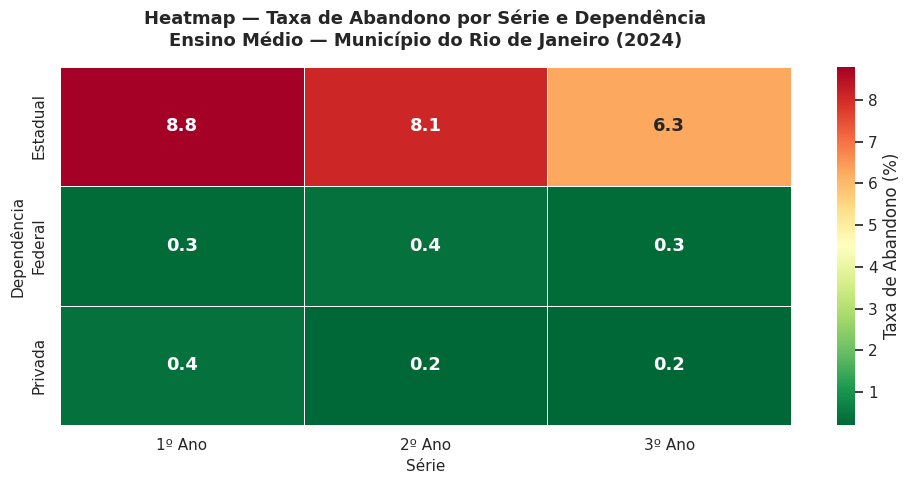

In [22]:
# Plotar heatmap
fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(
    df_heatmap_medio,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Taxa de Abandono (%)'},
    ax=ax,
    annot_kws={'size': 13, 'weight': 'bold'}
)

ax.set_title('Heatmap — Taxa de Abandono por Série e Dependência\nEnsino Médio — Município do Rio de Janeiro (2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Série', fontsize=11)
ax.set_ylabel('Dependência', fontsize=11)
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.savefig('grafico6_heatmap_medio.png', dpi=150, bbox_inches='tight')
plt.show()

# 9.3 — Heatmap: Abandono por série e dependência — Ensino Fundamental

Matriz — Abandono Ensino Fundamental por Dependência e Série:
           1º Ano  2º Ano  3º Ano  4º Ano  5º Ano  6º Ano  7º Ano  8º Ano  \
Estadual      0.0     0.0     0.0     0.0     0.0     0.2     0.0     0.6   
Municipal     0.2     0.1     0.1     0.1     0.2     0.4     0.4     0.5   
Federal       5.1     2.6     0.7     0.0     0.0     0.0     0.0     0.1   
Privada       0.1     0.1     0.0     0.1     0.0     0.1     0.0     0.1   

           9º Ano  
Estadual      0.4  
Municipal     0.4  
Federal       0.0  
Privada       0.1  


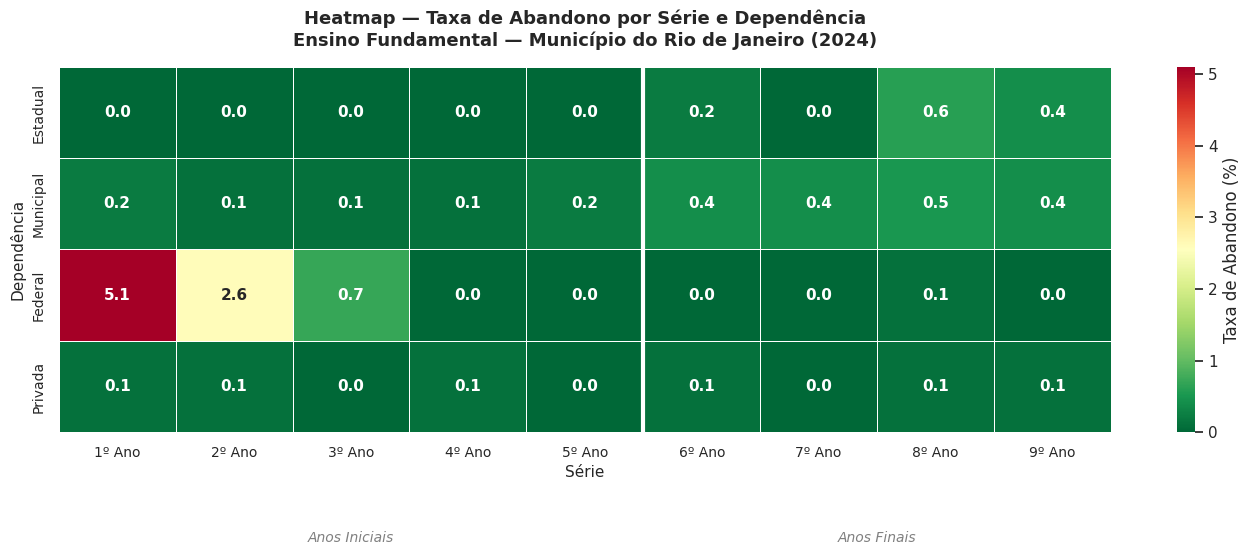

In [23]:
# Montar matriz para o heatmap do Fundamental
series_fun = [
    '1º Ano', '2º Ano', '3º Ano', '4º Ano', '5º Ano',
    '6º Ano', '7º Ano', '8º Ano', '9º Ano'
]

dados_heatmap_fun = {
    'Estadual': estadual_fun,
    'Municipal': municipal_fun,
    'Federal': federal_fun,
    'Privada': privada_fun
}

df_heatmap_fun = pd.DataFrame(
    dados_heatmap_fun,
    index=series_fun
).T

print("Matriz — Abandono Ensino Fundamental por Dependência e Série:")
print(df_heatmap_fun)

# Plotar heatmap
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    df_heatmap_fun,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Taxa de Abandono (%)'},
    ax=ax,
    annot_kws={'size': 11, 'weight': 'bold'}
)

# Linha separando anos iniciais dos anos finais
ax.axvline(x=5, color='white', linewidth=3)

# Anotações anos iniciais e finais
ax.text(2.5, -0.3, 'Anos Iniciais', ha='center',
        fontsize=10, color='gray', style='italic',
        transform=ax.get_xaxis_transform())
ax.text(7.0, -0.3, 'Anos Finais', ha='center',
        fontsize=10, color='gray', style='italic',
        transform=ax.get_xaxis_transform())

ax.set_title('Heatmap — Taxa de Abandono por Série e Dependência\nEnsino Fundamental — Município do Rio de Janeiro (2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Série', fontsize=11)
ax.set_ylabel('Dependência', fontsize=11)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.savefig('grafico7_heatmap_fundamental.png', dpi=150, bbox_inches='tight')
plt.show()

# 9.4 -Análise e Construção dos Dados - Boxplot - Distribuição do abandono nos municípios do estado do RJ

In [24]:
# Preparar dados para o boxplot
# Comparar distribuição do abandono médio e fundamental
# nos 92 municípios do estado do RJ por dependência

df_rj_estadual_todos = df[
    (df['uf'] == 'RJ') &
    (df['localizacao'] == 'Total') &
    (df['dependencia'] == 'Estadual')
].copy()

df_rj_municipal_todos = df[
    (df['uf'] == 'RJ') &
    (df['localizacao'] == 'Total') &
    (df['dependencia'] == 'Municipal')
].copy()

df_rj_privada_todos = df[
    (df['uf'] == 'RJ') &
    (df['localizacao'] == 'Total') &
    (df['dependencia'] == 'Privada')
].copy()

# Aplicar tratamento
for recorte in [df_rj_estadual_todos, df_rj_municipal_todos, df_rj_privada_todos]:
    for col in todas_metricas:
        recorte[col] = recorte[col].replace('--', np.nan)
        recorte[col] = pd.to_numeric(recorte[col], errors='coerce')

# Montar DataFrame para o boxplot
df_box = pd.DataFrame({
    'Abandono (%)': pd.concat([
        df_rj_estadual_todos['abandono_medio'].dropna(),
        df_rj_municipal_todos['abandono_fundamental'].dropna(),
        df_rj_privada_todos['abandono_medio'].dropna()
    ]),
    'Grupo': (
        ['Estadual — Médio'] * df_rj_estadual_todos['abandono_medio'].dropna().shape[0] +
        ['Municipal — Fundamental'] * df_rj_municipal_todos['abandono_fundamental'].dropna().shape[0] +
        ['Privada — Médio'] * df_rj_privada_todos['abandono_medio'].dropna().shape[0]
    )
})

print(f"Registros por grupo:")
print(df_box['Grupo'].value_counts())
print(f"\nEstatísticas descritivas:")
print(df_box.groupby('Grupo')['Abandono (%)'].describe().round(2))

Registros por grupo:
Grupo
Estadual — Médio           92
Municipal — Fundamental    92
Privada — Médio            67
Name: count, dtype: int64

Estatísticas descritivas:
                         count  mean   std  min  25%   50%   75%   max
Grupo                                                                 
Estadual — Médio          92.0  3.36  2.29  0.0  1.4  3.25  5.00  10.4
Municipal — Fundamental   92.0  0.37  0.40  0.0  0.0  0.20  0.62   1.8
Privada — Médio           67.0  0.16  0.44  0.0  0.0  0.00  0.10   2.8


# 9.5 - Gráfico - Boxplot - Distribuição do abandono nos municípios do estado do RJ

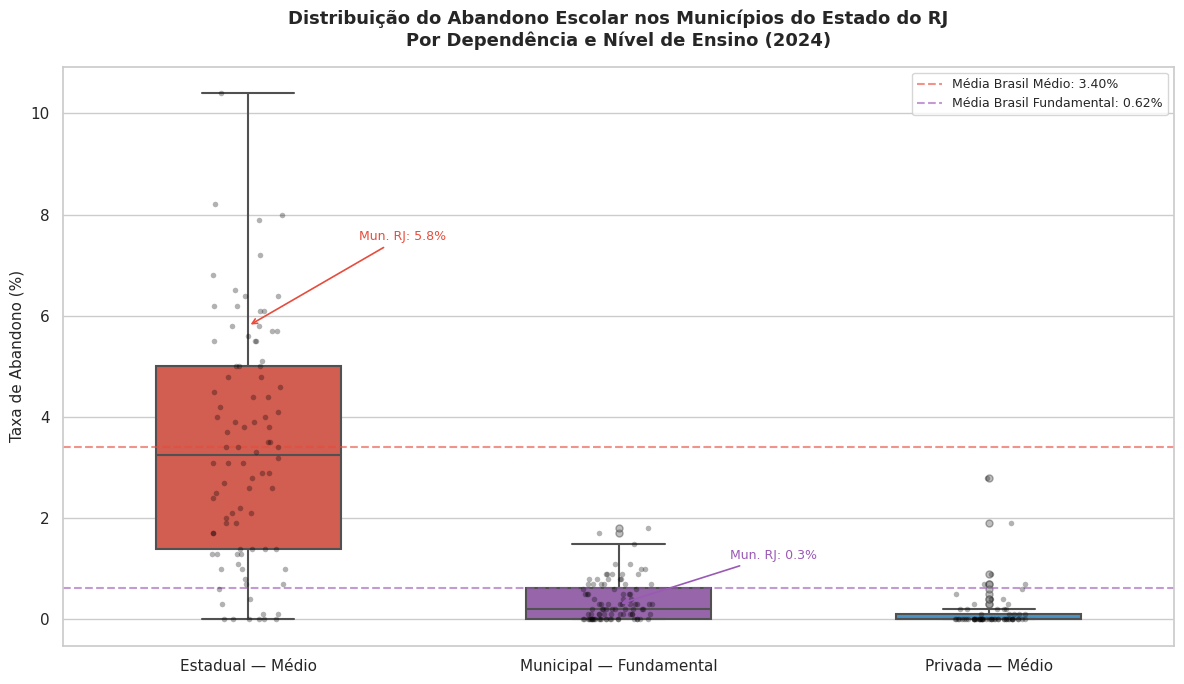

In [25]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.boxplot(
    data=df_box,
    x='Grupo',
    y='Abandono (%)',
    palette=['#E74C3C', '#9B59B6', '#3498DB'],
    width=0.5,
    linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor='gray',
                    markersize=5, alpha=0.5),
    ax=ax
)

# Adicionar pontos individuais sobre o boxplot
sns.stripplot(
    data=df_box,
    x='Grupo',
    y='Abandono (%)',
    color='black',
    alpha=0.3,
    size=4,
    jitter=True,
    ax=ax
)

# Linha de referência — média Brasil Ensino Médio
ax.axhline(y=media_brasil_medio, color='#E74C3C',
           linestyle='--', alpha=0.6,
           label=f'Média Brasil Médio: {media_brasil_medio:.2f}%')

# Linha de referência — média Brasil Fundamental
ax.axhline(y=media_brasil_fundamental, color='#9B59B6',
           linestyle='--', alpha=0.6,
           label=f'Média Brasil Fundamental: {media_brasil_fundamental:.2f}%')

# Anotar o município do Rio de Janeiro em cada grupo
ax.annotate(f'Mun. RJ: 5.8%',
            xy=(0, 5.8), xytext=(0.3, 7.5),
            fontsize=9, color='#E74C3C',
            arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.2))

ax.annotate(f'Mun. RJ: 0.3%',
            xy=(1, 0.3), xytext=(1.3, 1.2),
            fontsize=9, color='#9B59B6',
            arrowprops=dict(arrowstyle='->', color='#9B59B6', lw=1.2))

ax.set_title('Distribuição do Abandono Escolar nos Municípios do Estado do RJ\nPor Dependência e Nível de Ensino (2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('', fontsize=11)
ax.set_ylabel('Taxa de Abandono (%)', fontsize=11)
ax.tick_params(axis='x', labelsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('grafico8_boxplot_municipios_rj.png', dpi=150, bbox_inches='tight')
plt.show()

# 9.6 - Análise de Dados - Heatmap - Comparativo por região do Brasil

In [26]:
# Médias de abandono por região
regioes = ['Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste']

indicadores = {
    'Abandono Médio':           'abandono_medio',
    'Abandono Fundamental':     'abandono_fundamental',
    'Abandono Anos Iniciais':   'abandono_fun_anos_iniciais',
    'Abandono Anos Finais':     'abandono_fun_anos_finais',
}

# Calcular médias por região
dados_regioes = {}
for regiao in regioes:
    df_regiao = df_total[df_total['regiao'] == regiao].copy()
    for col in todas_metricas:
        df_regiao[col] = df_regiao[col].replace('--', np.nan)
        df_regiao[col] = pd.to_numeric(df_regiao[col], errors='coerce')
    dados_regioes[regiao] = {
        label: df_regiao[col].mean()
        for label, col in indicadores.items()
    }

df_heatmap_regioes = pd.DataFrame(dados_regioes).T
df_heatmap_regioes = df_heatmap_regioes.round(2)

print("Médias por região:")
print(df_heatmap_regioes)

Médias por região:
              Abandono Médio  Abandono Fundamental  Abandono Anos Iniciais  \
Norte                   3.28                  1.16                    0.46   
Nordeste                3.98                  0.99                    0.32   
Sudeste                 3.57                  0.47                    0.07   
Sul                     3.12                  0.25                    0.06   
Centro-Oeste            1.42                  0.22                    0.07   

              Abandono Anos Finais  
Norte                         2.06  
Nordeste                      1.78  
Sudeste                       0.93  
Sul                           0.49  
Centro-Oeste                  0.42  


# 9.7 - Gráfico Heatmap - Comparativo por regiao do Brasil

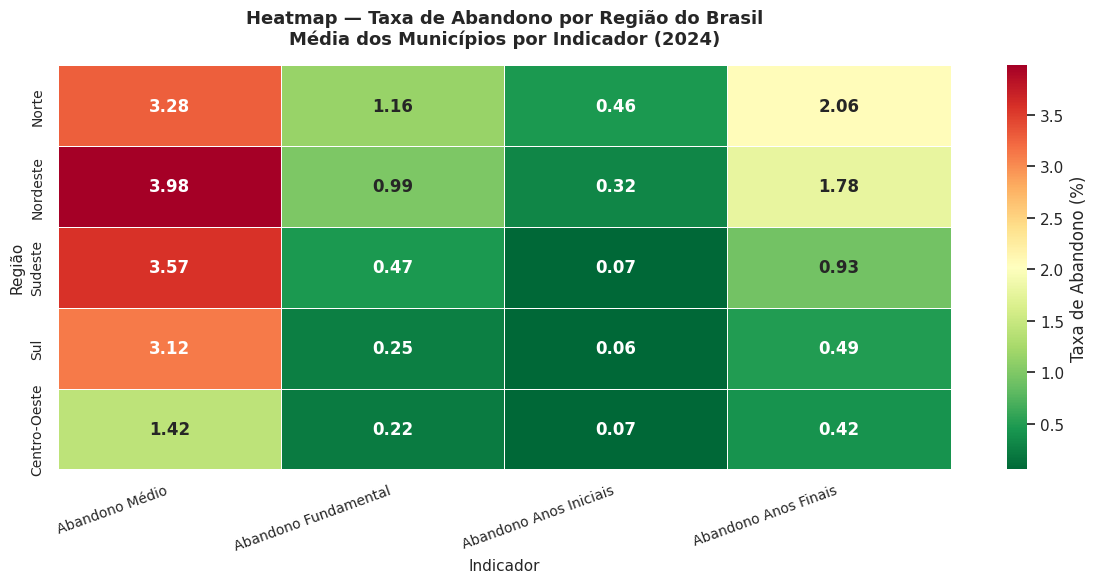

In [27]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(
    df_heatmap_regioes,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Taxa de Abandono (%)'},
    ax=ax,
    annot_kws={'size': 12, 'weight': 'bold'}
)

ax.set_title('Heatmap — Taxa de Abandono por Região do Brasil\nMédia dos Municípios por Indicador (2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Indicador', fontsize=11)
ax.set_ylabel('Região', fontsize=11)
ax.tick_params(axis='both', labelsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.savefig('grafico9_heatmap_regioes.png', dpi=150, bbox_inches='tight')
plt.show()

# CÉLULA 10 - EXPORTAR CSVs PARA O LOOKER STUDIO

In [28]:
import os

# Criar pasta para os arquivos
os.makedirs('exports', exist_ok=True)

# CSV 1 — Município do Rio de Janeiro por dependência
# Para gráficos de comparativo por dependência
df_export_dependencia = pd.DataFrame({
    'dependencia': ['Total', 'Pública', 'Estadual', 'Federal', 'Municipal', 'Privada'],
    'abandono_medio': [
        df_mun_rj_total['abandono_medio'].values[0],
        df_mun_rj_publica['abandono_medio'].values[0],
        df_mun_rj_estadual['abandono_medio'].values[0],
        df_mun_rj_federal['abandono_medio'].values[0],
        float('nan'),
        df_mun_rj_privada['abandono_medio'].values[0]
    ],
    'abandono_fundamental': [
        df_mun_rj_total['abandono_fundamental'].values[0],
        df_mun_rj_publica['abandono_fundamental'].values[0],
        df_mun_rj_estadual['abandono_fundamental'].values[0],
        df_mun_rj_federal['abandono_fundamental'].values[0],
        df_mun_rj_municipal['abandono_fundamental'].values[0],
        df_mun_rj_privada['abandono_fundamental'].values[0]
    ],
    'abandono_fun_anos_iniciais': [
        df_mun_rj_total['abandono_fun_anos_iniciais'].values[0],
        df_mun_rj_publica['abandono_fun_anos_iniciais'].values[0],
        df_mun_rj_estadual['abandono_fun_anos_iniciais'].values[0],
        df_mun_rj_federal['abandono_fun_anos_iniciais'].values[0],
        df_mun_rj_municipal['abandono_fun_anos_iniciais'].values[0],
        df_mun_rj_privada['abandono_fun_anos_iniciais'].values[0]
    ],
    'abandono_fun_anos_finais': [
        df_mun_rj_total['abandono_fun_anos_finais'].values[0],
        df_mun_rj_publica['abandono_fun_anos_finais'].values[0],
        df_mun_rj_estadual['abandono_fun_anos_finais'].values[0],
        df_mun_rj_federal['abandono_fun_anos_finais'].values[0],
        df_mun_rj_municipal['abandono_fun_anos_finais'].values[0],
        df_mun_rj_privada['abandono_fun_anos_finais'].values[0]
    ]
})

df_export_dependencia.to_csv('exports/01_municipio_rj_dependencia.csv',
                              index=False, decimal='.', sep=',')
print("✅ CSV 1 salvo — municipio_rj_dependencia")

# CSV 2 — Séries do Ensino Médio por dependência
df_export_medio_series = pd.DataFrame({
    'serie': ['1º Ano', '2º Ano', '3º Ano'],
    'estadual_abandono': estadual[:3],
    'federal_abandono': federal[:3],
    'privada_abandono': privada[:3],
    'media_brasil': [
        df_estadual_brasil['abandono_med_1ano'].mean(),
        df_estadual_brasil['abandono_med_2ano'].mean(),
        df_estadual_brasil['abandono_med_3ano'].mean()
    ]
})

df_export_medio_series.to_csv('exports/02_series_ensino_medio.csv',
                               index=False, decimal='.', sep=',')
print("✅ CSV 2 salvo — series_ensino_medio")

# CSV 3 — Séries do Ensino Fundamental por dependência
df_export_fun_series = pd.DataFrame({
    'serie': series_fundamental,
    'estadual_abandono': estadual_fun,
    'municipal_abandono': municipal_fun,
    'federal_abandono': federal_fun,
    'privada_abandono': privada_fun
})

df_export_fun_series.to_csv('exports/03_series_ensino_fundamental.csv',
                             index=False, decimal='.', sep=',')
print("✅ CSV 3 salvo — series_ensino_fundamental")

# CSV 4 — Ranking das capitais
df_export_capitais = df_capitais[[
    'uf', 'municipio', 'abandono_medio', 'abandono_fundamental'
]].copy()
df_export_capitais['capital'] = True
df_export_capitais['destaque'] = df_export_capitais['municipio'].apply(
    lambda x: 'Rio de Janeiro' if x == 'Rio de Janeiro' else 'Outras capitais'
)

df_export_capitais.to_csv('exports/04_ranking_capitais.csv',
                           index=False, decimal='.', sep=',')
print("✅ CSV 4 salvo — ranking_capitais")

# CSV 5 — Comparativo por região
df_heatmap_regioes_export = df_heatmap_regioes.reset_index()
df_heatmap_regioes_export.columns = [
    'regiao', 'abandono_medio', 'abandono_fundamental',
    'abandono_anos_iniciais', 'abandono_anos_finais'
]

df_heatmap_regioes_export.to_csv('exports/05_comparativo_regioes.csv',
                                  index=False, decimal='.', sep=',')
print("✅ CSV 5 salvo — comparativo_regioes")

# CSV 6 — Municípios do estado do RJ completo
df_rj_export = df_rj[[
    'municipio', 'abandono_medio', 'abandono_fundamental',
    'abandono_fun_anos_iniciais', 'abandono_fun_anos_finais',
    'aprov_fundamental', 'aprov_medio',
    'reprov_fundamental', 'reprov_medio'
]].copy()

df_rj_export.to_csv('exports/06_municipios_estado_rj.csv',
                     index=False, decimal='.', sep=',')
print("✅ CSV 6 salvo — municipios_estado_rj")

print(f"\n✅ Todos os CSVs exportados na pasta exports/")
print(f"Total de arquivos: 6 CSVs prontos para o Looker Studio")

✅ CSV 1 salvo — municipio_rj_dependencia
✅ CSV 2 salvo — series_ensino_medio
✅ CSV 3 salvo — series_ensino_fundamental
✅ CSV 4 salvo — ranking_capitais
✅ CSV 5 salvo — comparativo_regioes
✅ CSV 6 salvo — municipios_estado_rj

✅ Todos os CSVs exportados na pasta exports/
Total de arquivos: 6 CSVs prontos para o Looker Studio


In [30]:
# CÉLULA ADICIONAL — Correção exportação CSV 6
# Lendo direto do arquivo original sem alterar nenhum DataFrame existente

df_raw_rj = pd.read_excel(
    'tx_rend_municipios_2024.xlsx',
    sheet_name='MUNICIPIOS ',
    skiprows=8,
    header=0
)

# Filtrar estado RJ com Total/Total
df_rj_estado = df_raw_rj[
    (df_raw_rj['NO_REGIAO'].notna()) &
    (df_raw_rj['SG_UF'] == 'RJ') &
    (df_raw_rj['NO_CATEGORIA'] == 'Total') &
    (df_raw_rj['NO_DEPENDENCIA'] == 'Total')
].copy()

# Selecionar e renomear colunas necessárias
df_rj_estado_export = df_rj_estado[[
    'NO_MUNICIPIO', '1_CAT_FUN', '1_CAT_MED',
    '1_CAT_FUN_AI', '1_CAT_FUN_AF',
    '2_CAT_FUN', '2_CAT_MED',
    '3_CAT_FUN', '3_CAT_MED'
]].copy()

df_rj_estado_export.columns = [
    'municipio', 'aprov_fundamental', 'aprov_medio',
    'aprov_fun_anos_iniciais', 'aprov_fun_anos_finais',
    'reprov_fundamental', 'reprov_medio',
    'abandono_fundamental', 'abandono_medio'
]

# Tratar valores
for col in df_rj_estado_export.columns[1:]:
    df_rj_estado_export[col] = df_rj_estado_export[col].replace('--', np.nan)
    df_rj_estado_export[col] = pd.to_numeric(df_rj_estado_export[col], errors='coerce')

print(f"Total de municípios: {len(df_rj_estado_export)}")
print(df_rj_estado_export['municipio'].head(10).tolist())

# Exportar
df_rj_estado_export.to_csv('exports/06_municipios_estado_rj_v2.csv',
                            index=False, decimal='.', sep=',')
print("✅ CSV 6 corrigido exportado!")

Total de municípios: 92
['Angra dos Reis', 'Aperibé', 'Araruama', 'Areal', 'Armação dos Búzios', 'Arraial do Cabo', 'Barra do Piraí', 'Barra Mansa', 'Belford Roxo', 'Bom Jardim']
✅ CSV 6 corrigido exportado!
